# Retail Credit Risk Model - PD, LGD, EAD & IFRS 9 ECL
### Lending Club 2016–2018 | WoE · Logistic Regression · Stress Testing

This notebook develops an end-to-end credit risk model on Lending Club loan data covering the following components:

1. **Data preparation** - filtering to resolved loans, year-based train/test split, feature cleaning  
2. **Feature selection** - IV analysis, WoE transformation across numeric and categorical features  
3. **PD model** - two logistic regression variants (origination-only vs. pricing-inclusive), scorecard conversion, AUC/KS validation  
4. **Expected loss framework** - empirical LGD by grade, EAD, ECL = PD × LGD × EAD  
5. **IFRS 9 staging** - three-stage classification with 12-month vs. lifetime ECL horizon  
6. **Stress testing** - base / adverse / severe macro scenarios with ECL uplift  
7. **Backtest validation** - provisioned ECL vs. realised losses on the 2018 holdout cohort  
8. **Policy simulation** - risk-based rejection cutoff and its effect on expected loss

## 1. Data Loading & Preparation

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import xgboost as xgb

import warnings
from dotenv import load_dotenv
warnings.filterwarnings('ignore')

In [2]:
# Columns required - financial features available at origination, plus
# outcome fields (loan_status, recoveries, total_rec_prncp) needed for
# target construction and LGD estimation
cols = [
    "id", "loan_amnt", "term", "int_rate", "installment",
    "grade", "sub_grade", "purpose", "application_type",
    "annual_inc", "verification_status", "emp_length",
    "home_ownership", "dti", "addr_state",
    "fico_range_low", "fico_range_high",
    "delinq_2yrs", "inq_last_6mths", "open_acc",
    "pub_rec", "revol_bal", "revol_util", "total_acc",
    "pub_rec_bankruptcies", "tax_liens",
    "issue_d", "loan_status", "last_pymnt_d",
    "total_rec_prncp", "recoveries", "total_pymnt"
]

load_dotenv()
file_path = os.getenv('LC_DATA_PATH')
df = pd.read_csv(file_path, usecols=cols, low_memory=False)
df.head(3)

,id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,total_rec_prncp,recoveries,last_pymnt_d,application_type,pub_rec_bankruptcies,tax_liens
0,1077501,5000.0,36 months,10.65%,162.87,B,B2,10+ years,RENT,24000.0,Verified,Dec-2011,Fully Paid,credit_card,AZ,27.65,0.0,735.0,739.0,1.0,3.0,0.0,13648.0,83.7%,9.0,5863.155187,5000.00,0.0,Jan-2015,Individual,0.0,0.0
1,1077430,2500.0,60 months,15.27%,59.83,C,C4,< 1 year,RENT,30000.0,Source Verified,Dec-2011,Charged Off,car,GA,1.00,0.0,740.0,744.0,5.0,3.0,0.0,1687.0,9.4%,4.0,1014.530000,456.46,122.9,Apr-2013,Individual,0.0,0.0
2,1077175,2400.0,36 months,15.96%,84.33,C,C5,10+ years,RENT,12252.0,Not Verified,Dec-2011,Fully Paid,small_business,IL,8.72,0.0,735.0,739.0,2.0,2.0,0.0,2956.0,98.5%,10.0,3005.666844,2400.00,0.0,Jun-2014,Individual,0.0,0.0


In [3]:
# Preserve the full raw frame - needed later for LGD estimation and backtest
# (recoveries and total_rec_prncp are dropped from df_train but kept in df0)
df0 = df.copy()

In [4]:
# Extract origination year for cohort filtering and train/test splitting
df0['issue_year'] = df0['issue_d'].str[-4:]

# Retain only 2016–2019 originations - earlier vintages have structurally different
# credit environments; 2020 adds COVID noise
df0 = df0[df0['issue_d'].str.contains('2016|2017|2018|2019', na=False)]
df0.shape

(1891335, 33)

In [5]:
# Keep only fully resolved loans - Current/Late status loans have unknown outcomes
# and would introduce noise into default rate estimation
df0 = df0[df0['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]

# Binary target: 1 = default (Charged Off or Default), 0 = performing (Fully Paid)
df0['default_flag'] = df0['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Default'] else 0
)

df0['default_flag'].value_counts(normalize=True).round(3)

default_flag
0    0.792
1    0.208
Name: proportion, dtype: float64

### 1.1 Cleaning

In [6]:
# Strip string formatting from rate and term columns
df0['int_rate'] = df0['int_rate'].str.replace('%', '').astype(float)
df0['term']     = df0['term'].str.replace(' months', '').astype(int)

In [7]:
# Drop columns that are either post-origination (data leakage risk) or
# captured in the target variable already
df0 = df0.drop(columns=['issue_d', 'loan_status'])

In [8]:
(df0.isna().mean()*100).sort_values(ascending=False)

emp_length              7.372318
last_pymnt_d            0.264127
dti                     0.110802
revol_util              0.094237
inq_last_6mths          0.000101
int_rate                0.000000
term                    0.000000
id                      0.000000
sub_grade               0.000000
home_ownership          0.000000
verification_status     0.000000
annual_inc              0.000000
purpose                 0.000000
installment             0.000000
grade                   0.000000
loan_amnt               0.000000
fico_range_low          0.000000
delinq_2yrs             0.000000
addr_state              0.000000
open_acc                0.000000
pub_rec                 0.000000
revol_bal               0.000000
total_acc               0.000000
fico_range_high         0.000000
total_pymnt             0.000000
total_rec_prncp         0.000000
recoveries              0.000000
application_type        0.000000
pub_rec_bankruptcies    0.000000
tax_liens               0.000000
issue_year

**Missing value summary:**  
`emp_length` is ~7.4% missing - manageable with imputation. `last_pymnt_d` is a post-origination field irrelevant to scoring. `dti` and `revol_util` are under 0.2% missing - imputed at the median. No core variable is dropped at this stage.

### 1.2 Train / Test Split

Year-based split rather than random - this respects the temporal nature of lending data and prevents leakage from future observations into the training set.

- **Train**: 2016–2017 originations (~717k resolved loans)  
- **Test**: 2018 originations (~197k resolved loans)  
- **Excluded**: 2019 is right-censored - most loans originated in 2019 had not resolved by the dataset snapshot, so only the worst early-defaulters appear. Including them would bias the training default rate upward.

In [9]:
df_model = df0[df0['issue_year'].isin(['2016', '2017', '2018'])].drop(columns=['last_pymnt_d'])

# Standardise emp_length to numeric years (< 1 year → 0, 10+ years → 10)
df_model['emp_length'] = (
    df_model['emp_length']
    .str.replace(' years', '', regex=False)
    .str.replace(' year',  '', regex=False)
    .str.replace('< 1',    '0', regex=False)
    .str.replace('10+',    '10', regex=False)
)
df_model['emp_length'] = pd.to_numeric(df_model['emp_length'], errors='coerce')

In [10]:
df_train = df_model[df_model['issue_year'] == '2016']
df_train = pd.concat([df_train, df_model[df_model['issue_year'] == '2017']])
df_test  = df_model[df_model['issue_year'] == '2018']

print(f"Train: {len(df_train):,} loans | Test: {len(df_test):,} loans")

Train: 717,472 loans | Test: 197,178 loans


In [11]:
# Sanity check: default rates should be broadly stable across years
# Large divergence would suggest cohort-specific effects needing investigation
df_model.groupby('issue_year')['default_flag'].mean().round(3)

issue_year
2016    0.196
2017    0.211
2018    0.240
Name: default_flag, dtype: float64

### Vintage Analysis: Default Rate by Grade and Origination Year

Aggregate default rates are broadly stable across 2016-2018, but a grade-level breakdown reveals systematic deterioration in the 2018 cohort across every grade. This vintage effect is independent of grade rank ordering and suggests underwriting drift or adverse macro conditions in 2018. It confirms the year-based train/test split is the correct approach: random sampling would blend 2018's elevated risk profile into the training set, biasing PD estimates downward.

In [12]:
# Default rate by origination year and grade
# 2019 excluded: insufficient resolved loans to produce meaningful rates
vintage = (
    df_model
    .groupby(['issue_year', 'grade'])['default_flag']
    .agg(total='count', defaults='sum')
    .reset_index()
)
vintage['default_rate'] = (vintage['defaults'] / vintage['total'] * 100).round(2)

pivot = vintage.pivot(index='grade', columns='issue_year', values='default_rate')
print(pivot)

issue_year   2016   2017   2018
grade                          
A            5.94   6.62   9.12
B           13.21  14.86  19.40
C           22.14  25.09  29.72
D           31.52  33.24  37.96
E           41.21  40.50  43.81
F           50.59  48.04  52.24
G           54.90  51.59  54.39


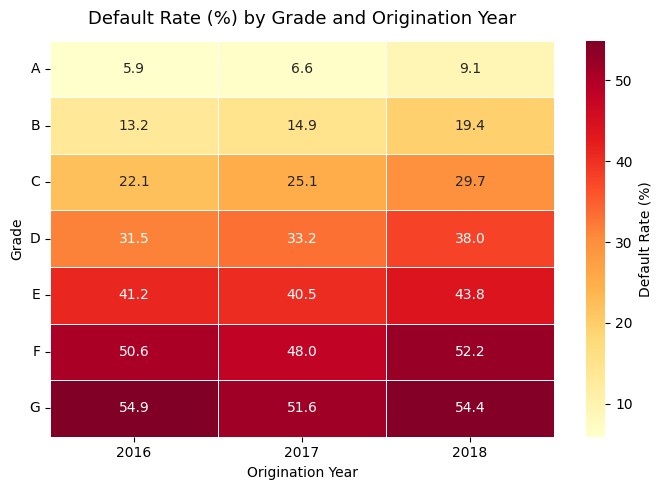

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Default Rate (%)'}
)

ax.set_title('Default Rate (%) by Grade and Origination Year', fontsize=13, pad=12)
ax.set_xlabel('Origination Year')
ax.set_ylabel('Grade')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# Drop issue_year - used for split only, not a valid origination feature
df_train = df_train.drop(columns=['issue_year'])
df_test  = df_test.drop(columns=['issue_year'])

In [15]:
# Remove outcome fields from training set - these are not available at origination
# and would cause data leakage. Kept in df_test and df0 for LGD estimation and backtest.
df_train.drop(columns=['total_rec_prncp', 'recoveries', 'total_pymnt'], inplace=True)

## 2. Feature Engineering & WoE Transformation

### 2.1 Feature Selection via Information Value

Information Value (IV) measures the predictive power of each feature with respect to the default flag. The threshold guidance is: IV < 0.02 (useless), 0.02–0.1 (weak), 0.1–0.3 (medium), > 0.3 (strong).

Each feature is first binned and its default rate examined for monotonicity - a key requirement for regulatory scorecard models.

In [16]:
# Check DTI distribution to identify capping threshold before encoding
# Extreme outliers (DTI > 100%) are data quality issues - capped rather than dropped
df_train['dti'].quantile([0.95, 0.99, 0.995, 0.999])

0.950    33.47000
0.990    41.92000
0.995    49.44000
0.999    94.32917
Name: dti, dtype: float64

In [17]:
# Remove negative DTI (data errors) and cap extreme outliers at 100
df_train = df_train[df_train['dti'] >= 0]
df_train.loc[df_train['dti'] > 100, 'dti'] = 100

df_test = df_test[df_test['dti'] >= 0]
df_test.loc[df_test['dti'] > 100, 'dti'] = 100

In [18]:
# Binned default rate - confirms monotonic relationship (higher DTI → higher default)
df_train['dti_bin'] = pd.qcut(df_train['dti'], q=10, duplicates='drop')
df_train.groupby('dti_bin')['default_flag'].mean().round(3)

dti_bin
(-0.001, 7.42]    0.161
(7.42, 10.71]     0.162
(10.71, 13.29]    0.170
(13.29, 15.64]    0.179
(15.64, 17.99]    0.190
(17.99, 20.45]    0.200
(20.45, 23.15]    0.212
(23.15, 26.33]    0.229
(26.33, 30.44]    0.248
(30.44, 100.0]    0.275
Name: default_flag, dtype: float64

In [19]:
# fico_range_low and fico_range_high are near-perfectly correlated - use only one
df_train[['fico_range_low', 'fico_range_high']].corr()

,fico_range_low,fico_range_high
fico_range_low,1.0,1.0
fico_range_high,1.0,1.0


In [20]:
# Binned default rate by FICO - confirms strong monotonic inverse relationship
df_train['fico_bin'] = pd.qcut(df_train['fico_range_low'], q=10, duplicates='drop')
df_train.groupby('fico_bin')['default_flag'].mean().round(3)

fico_bin
(659.999, 665.0]    0.262
(665.0, 670.0]      0.246
(670.0, 675.0]      0.241
(675.0, 680.0]      0.232
(680.0, 690.0]      0.217
(690.0, 700.0]      0.200
(700.0, 710.0]      0.179
(710.0, 720.0]      0.161
(720.0, 740.0]      0.138
(740.0, 845.0]      0.100
Name: default_flag, dtype: float64

### Weight of Evidence (WoE) & Information Value

WoE transforms each feature bin into a single numeric value representing the log-odds of being a non-default vs. a default in that bin. This linearises the relationship for logistic regression and handles non-monotonicity naturally.

`WoE = ln(Distribution of Goods / Distribution of Bads)`  
`IV = Σ (Dist_Goods − Dist_Bads) × WoE`

A 0.5 Laplace smoothing is applied to bins with zero events to avoid infinite log values.

In [21]:
def compute_iv(df, feature, target, bins=10):
    temp = df[[feature, target]].copy()

    # Bin numeric features by quantile; categoricals used as-is
    if pd.api.types.is_numeric_dtype(temp[feature]):
        temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')
    else:
        temp['bin'] = temp[feature]

    grouped = temp.groupby('bin', observed=False)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bads']
    grouped['goods'] = grouped['total'] - grouped['bads']

    # Laplace smoothing to prevent log(0)
    grouped['goods'] = grouped['goods'] + 0.5
    grouped['bads']  = grouped['bads']  + 0.5

    grouped['dist_goods'] = grouped['goods'] / grouped['goods'].sum()
    grouped['dist_bads']  = grouped['bads']  / grouped['bads'].sum()

    grouped['woe'] = np.log(grouped['dist_goods'] / grouped['dist_bads'])
    grouped['iv']  = (grouped['dist_goods'] - grouped['dist_bads']) * grouped['woe']

    return grouped['iv'].sum(), grouped

In [22]:
# Strip % sign before analysis
df_train['revol_util'] = df_train['revol_util'].str.replace('%', '').astype(float)
df_test['revol_util']  = df_test['revol_util'].str.replace('%', '').astype(float)

In [23]:
# Cap at 110% - values above are data errors (revolving utilisation cannot meaningfully
# exceed 100%; a small buffer accommodates rounding in source systems)
df_train.loc[df_train['revol_util'] > 110, 'revol_util'] = 110
df_test.loc[df_test['revol_util']  > 110, 'revol_util'] = 110

In [24]:
# IV summary across all candidate numeric features
# Features with IV < 0.02 are not worth encoding; > 0.1 are strong candidates
features = [
    "fico_range_low", "dti", "revol_util", "annual_inc",
    "inq_last_6mths", "open_acc", "pub_rec", "total_acc", "emp_length"
]
iv_dict = {col: compute_iv(df_train, col, 'default_flag')[0] for col in features}
pd.Series(iv_dict).sort_values(ascending=False).round(4)

fico_range_low    0.1103
dti               0.0498
inq_last_6mths    0.0236
revol_util        0.0230
annual_inc        0.0207
open_acc          0.0033
emp_length        0.0030
total_acc         0.0013
pub_rec           0.0009
dtype: float64

In [25]:
# Final feature set: numeric features with meaningful IV + key categoricals
# grade excluded - captures same signal as fico and int_rate but as a derived label
model_features = [
    'fico_range_low', 'dti', 'revol_util', 'inq_last_6mths', 'annual_inc',
    'home_ownership', 'verification_status', 'purpose', 'application_type',
    'default_flag'
]

df_train_model = df_train[model_features].copy()
df_test_model  = df_test[model_features].copy()

In [26]:
# IV for categorical features - decide which to include
cat_features = ['home_ownership', 'verification_status', 'purpose', 'application_type']
iv_cat = {col: compute_iv(df_train_model, col, 'default_flag')[0] for col in cat_features}
pd.Series(iv_cat).sort_values(ascending=False).round(4)

verification_status    0.0540
home_ownership         0.0311
purpose                0.0163
application_type       0.0031
dtype: float64

In [27]:
# purpose and application_type have low IV and many sparse categories - dropped
df_train_model = df_train_model.drop(columns=['purpose', 'application_type'])
df_test_model  = df_test_model.drop(columns=['purpose', 'application_type'])

### 2.2 Missing Value Imputation

Imputation uses training-set medians only - the same values are applied to the test set to prevent data leakage. 
Imputation must happen before WoE tables are computed so bin boundaries are fit on clean data.

In [28]:
# Impute with training median - applied to test set using the same value
for col in ['revol_util', 'annual_inc', 'inq_last_6mths']:
    median = df_train_model[col].median()
    df_train_model[col] = df_train_model[col].fillna(median)
    df_test_model[col]  = df_test_model[col].fillna(median)

In [29]:
# Zero income is treated as missing - implausible for a borrower seeking credit
df_train_model.loc[df_train_model['annual_inc'] == 0, 'annual_inc'] = np.nan
df_test_model.loc[df_test_model['annual_inc']   == 0, 'annual_inc'] = np.nan

median_income = df_train_model['annual_inc'].median()
df_train_model['annual_inc'].fillna(median_income, inplace=True)
df_test_model['annual_inc'].fillna(median_income, inplace=True)

### 2.3 WoE Encoding

WoE tables are computed on the training set only and then applied to both train and test - using training-set bin boundaries on the test set is the correct approach to avoid data leakage.

In [30]:
def apply_woe(df, feature, woe_table):
    """Map a feature to its WoE value using training-set bin boundaries.
    
    Numeric features are binned using the intervals from the training WoE table,
    then mapped to their WoE values. Categorical features are mapped directly.
    """
    woe_map = woe_table['woe']

    if isinstance(woe_table.index, pd.CategoricalIndex):
        # Numeric: apply training-set bin boundaries to avoid leakage
        intervals = woe_table.index.categories
        df[feature + '_bin'] = pd.cut(df[feature], bins=intervals, include_lowest=True)
        df[feature + '_bin'] = pd.Categorical(df[feature + '_bin'], categories=intervals)
        df[feature + '_woe'] = df[feature + '_bin'].map(woe_map)
    else:
        # Categorical: direct map
        df[feature + '_woe'] = df[feature].map(woe_map)

    return df

In [31]:
# Compute WoE tables for all selected features on the training set
iv_fico,  woe_fico  = compute_iv(df_train_model, 'fico_range_low',      'default_flag')
iv_dti,   woe_dti   = compute_iv(df_train_model, 'dti',                 'default_flag')
iv_revol, woe_revol = compute_iv(df_train_model, 'revol_util',          'default_flag')
iv_inq,   woe_inq   = compute_iv(df_train_model, 'inq_last_6mths',      'default_flag')
iv_inc,   woe_inc   = compute_iv(df_train_model, 'annual_inc',          'default_flag')
iv_home,  woe_home  = compute_iv(df_train_model, 'home_ownership',      'default_flag')
iv_ver,   woe_ver   = compute_iv(df_train_model, 'verification_status', 'default_flag')

In [32]:
# Apply WoE mapping for fico manually using training-set bin intervals
# apply_woe() handles the remaining features below.
fico_intervals = woe_fico.index.categories
df_train_model['fico_bin'] = pd.cut(df_train_model['fico_range_low'], bins=fico_intervals)
df_test_model['fico_bin']  = pd.cut(df_test_model['fico_range_low'],  bins=fico_intervals)

fico_woe_map = woe_fico['woe']
df_train_model['fico_woe'] = df_train_model['fico_bin'].map(fico_woe_map)
df_test_model['fico_woe']  = df_test_model['fico_bin'].map(fico_woe_map)

In [33]:
# Apply WoE transformation to remaining features using the generic helper
woe_tables = {
    'dti':                woe_dti,
    'revol_util':         woe_revol,
    'inq_last_6mths':     woe_inq,
    'annual_inc':         woe_inc,
    'home_ownership':     woe_home,
    'verification_status':woe_ver,
}
for feature, woe_table in woe_tables.items():
    df_train_model = apply_woe(df_train_model, feature, woe_table)
    df_test_model  = apply_woe(df_test_model,  feature, woe_table)

## 3. PD Model Development

### 3.1 Model A - Origination Features Only (Logistic Regression)

Model A uses only features available at loan origination - i.e., before any pricing decision is made. This is the more conservative model and avoids the endogeneity of using interest rate (which is partly a function of the lender's own risk assessment) as a predictor.

In [34]:
# Select WoE-encoded columns as model inputs
woe_cols = [col for col in df_train_model.columns if col.endswith('_woe')]

X_train = df_train_model[woe_cols]
y_train = df_train_model['default_flag']
X_test  = df_test_model[woe_cols]
y_test  = df_test_model['default_flag']

# First fit - used to inspect coefficient signs before feature refinement
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
# Inspect coefficients - all signs should be intuitive (positive WoE = lower risk
# should produce a negative coefficient; negative WoE = higher risk → positive coef)
coeff = pd.Series(model.coef_[0], index=woe_cols)
print(coeff.sort_values(ascending=False))

revol_util_woe             0.059245
annual_inc_woe            -0.352283
verification_status_woe   -0.616449
fico_woe                  -0.830789
home_ownership_woe        -0.836035
inq_last_6mths_woe        -0.873745
dti_woe                   -0.881710
dtype: float64


In [36]:
test_pred  = model.predict_proba(X_test)[:, 1]
test_auc  = roc_auc_score(y_test,  test_pred)

print(f"Test  AUC : {test_auc:.4f}  |  Gini: {round(2*test_auc-1,  4)}")

Test  AUC : 0.6326  |  Gini: 0.2651


**Feature refinement - dropping `revol_util_woe`:**

The initial coefficient on `revol_util_woe` showed a sign reversal - revolving utilisation was producing a positive coefficient (implying lower default probability), which contradicts the economic relationship and the IV analysis. This is a multicollinearity symptom: `revol_util` is correlated with `dti` and `inq_last_6mths`, which are absorbing its signal. It is removed and the model refit.

In [37]:
# Drop revol_util_woe from both sets - sign reversal identified in coefficient output
df_train_model = df_train_model.drop(columns=['revol_util_woe'], errors='ignore')
df_test_model  = df_test_model.drop(columns=['revol_util_woe'], errors='ignore')

# Redefine feature set and refit
woe_cols = [col for col in df_train_model.columns if col.endswith('_woe')]
X_train  = df_train_model[woe_cols]
X_test   = df_test_model[woe_cols]

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [38]:
# Final Model A coefficients - all signs should now be economically interpretable
coef = pd.Series(model.coef_[0], index=woe_cols)
print(coef.sort_values(ascending=False))

annual_inc_woe            -0.349939
verification_status_woe   -0.616014
fico_woe                  -0.817167
home_ownership_woe        -0.840283
dti_woe                   -0.879815
inq_last_6mths_woe        -0.880161
dtype: float64


In [39]:
train_pred = model.predict_proba(X_train)[:, 1]
test_pred  = model.predict_proba(X_test)[:, 1]

print(f"Model A Final — Train AUC: {round(roc_auc_score(y_train, train_pred), 4)}")
print(f"Model A Final — Test  AUC: {round(roc_auc_score(y_test,  test_pred),  4)}")

Model A Final — Train AUC: 0.629
Model A Final — Test  AUC: 0.6327


### 3.2 Credit Scorecard

The logistic regression outputs are converted to a points-based scorecard using the standard PDO (Points to Double the Odds) scaling. This makes the model interpretable to non-technical stakeholders.

- **PDO = 50**: score decreases by 50 points each time the odds of default double  
- **Anchor point**: score of 700 corresponds to odds of 1:20 (good:bad)  
- **Formula**: `Score = Offset − Factor × log(odds)`

In [40]:
PDO    = 50
factor = PDO / np.log(2)
offset = 700 + factor * np.log(1 / 20)

print(f"Factor: {factor:.2f}  |  Offset: {offset:.2f}")

Factor: 72.13  |  Offset: 483.90


In [41]:
# decision_function() returns the raw log-odds (linear combination of features)
log_odds_train = model.decision_function(X_train)
score_train    = offset - factor * log_odds_train
score_test     = offset - factor * model.decision_function(X_test)

print(f"Score range (train): {score_train.min():.0f} – {score_train.max():.0f}")

Score range (train): 475 – 695


In [42]:
# Score band default rates - monotonic decrease confirms scorecard direction is correct
df_test_model['score']      = score_test
df_test_model['score_band'] = pd.qcut(df_test_model['score'], q=10, duplicates='drop')
df_test_model.groupby('score_band')['default_flag'].mean().round(3)

score_band
(474.66, 552.807]     0.388
(552.807, 566.939]    0.327
(566.939, 577.117]    0.305
(577.117, 586.01]     0.273
(586.01, 594.879]     0.249
(594.879, 603.888]    0.227
(603.888, 614.344]    0.207
(614.344, 627.658]    0.183
(627.658, 645.998]    0.148
(645.998, 685.983]    0.090
Name: default_flag, dtype: float64

### 3.3 Model B - Pricing-Inclusive (Logistic Regression)

Model B adds `int_rate` as a feature. Interest rate is partly determined by the lender's own risk assessment (through grade), which introduces endogeneity. However, it captures additional market information and borrower risk premium. Model B is compared against Model A to quantify the lift from including pricing.

In [43]:
model_features_B = [
    'int_rate', 'fico_range_low', 'dti', 'inq_last_6mths',
    'annual_inc', 'home_ownership', 'verification_status', 'default_flag'
]
df_train_model = df_train[model_features_B].copy()
df_test_model  = df_test[model_features_B].copy()

In [44]:
# Impute medians - same approach as Model A
for col in ['annual_inc', 'inq_last_6mths']:
    median = df_train_model[col].median()
    df_train_model[col] = df_train_model[col].fillna(median)
    df_test_model[col]  = df_test_model[col].fillna(median)

df_train_model.loc[df_train_model['annual_inc'] == 0, 'annual_inc'] = np.nan
df_test_model.loc[df_test_model['annual_inc']   == 0, 'annual_inc'] = np.nan
median_income = df_train_model['annual_inc'].median()
df_train_model['annual_inc'].fillna(median_income, inplace=True)
df_test_model['annual_inc'].fillna(median_income, inplace=True)

In [45]:
# Recompute WoE tables on Model B feature set (includes int_rate)
iv_fico, woe_fico = compute_iv(df_train_model, 'fico_range_low',      'default_flag')
iv_dti,  woe_dti  = compute_iv(df_train_model, 'dti',                 'default_flag')
iv_inq,  woe_inq  = compute_iv(df_train_model, 'inq_last_6mths',      'default_flag')
iv_inc,  woe_inc  = compute_iv(df_train_model, 'annual_inc',          'default_flag')
iv_home, woe_home = compute_iv(df_train_model, 'home_ownership',      'default_flag')
iv_ver,  woe_ver  = compute_iv(df_train_model, 'verification_status', 'default_flag')
iv_int,  woe_int  = compute_iv(df_train_model, 'int_rate',            'default_flag')

In [46]:
woe_tables_B = {
    'fico_range_low':      woe_fico,
    'dti':                 woe_dti,
    'inq_last_6mths':      woe_inq,
    'annual_inc':          woe_inc,
    'home_ownership':      woe_home,
    'verification_status': woe_ver,
    'int_rate':            woe_int,
}
for feature, woe_table in woe_tables_B.items():
    df_train_model = apply_woe(df_train_model, feature, woe_table)
    df_test_model  = apply_woe(df_test_model,  feature, woe_table)

In [47]:
# Some test-set int_rate values fall outside training bins - fill with the
# most conservative (worst) WoE bin to avoid silent NaN propagation
df_test_model['int_rate_woe'].fillna(woe_int['woe'].min(), inplace=True)

In [48]:
# Drop intermediate bin columns - only WoE-encoded columns needed for modeling
df_train_model.drop(columns=[c for c in df_train_model.columns if c.endswith('_bin')], inplace=True)
df_test_model.drop( columns=[c for c in df_test_model.columns  if c.endswith('_bin')], inplace=True)

In [49]:
woe_cols_B = [col for col in df_train_model.columns if col.endswith('_woe')]

X_train_B = df_train_model[woe_cols_B]
y_train_B = df_train_model['default_flag']
X_test_B  = df_test_model[woe_cols_B]
y_test_B  = df_test_model['default_flag']

model_B = LogisticRegression(max_iter=1000)
model_B.fit(X_train_B, y_train_B)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [50]:
coef_B = pd.Series(model_B.coef_[0], index=woe_cols_B)
print(coef_B.sort_values(ascending=False))

annual_inc_woe            -0.113086
verification_status_woe   -0.175817
fico_range_low_woe        -0.201135
inq_last_6mths_woe        -0.390673
dti_woe                   -0.432147
home_ownership_woe        -0.730328
int_rate_woe              -0.898134
dtype: float64


In [51]:
train_auc_B = roc_auc_score(y_train_B, model_B.predict_proba(X_train_B)[:, 1])
test_auc_B  = roc_auc_score(y_test_B,  model_B.predict_proba(X_test_B)[:, 1])

print(f"Model A — Test AUC: 0.6327  |  Gini: 0.2654")
print(f"Model B — Test AUC: {round(test_auc_B, 4)}  |  Gini: {round(2*test_auc_B-1, 4)}")

Model A — Test AUC: 0.6327  |  Gini: 0.2654
Model B — Test AUC: 0.6763  |  Gini: 0.3526


### 3.4 KS Statistic

The Kolmogorov-Smirnov statistic measures the maximum separation between the cumulative distribution of predicted PDs for defaulters vs. non-defaulters. Higher KS = better discrimination. Typical acceptable range for retail credit models: 0.20–0.50.

In [52]:
# Model B KS
df_ks = pd.DataFrame({'y_true': y_test_B, 'pd': model_B.predict_proba(X_test_B)[:, 1]})
df_ks = df_ks.sort_values('pd', ascending=False).reset_index(drop=True)

total_bads  = df_ks['y_true'].sum()
total_goods = len(df_ks) - total_bads

df_ks['cum_bads']  = df_ks['y_true'].cumsum() / total_bads
df_ks['cum_goods'] = (1 - df_ks['y_true']).cumsum() / total_goods
df_ks['ks']        = df_ks['cum_bads'] - df_ks['cum_goods']

print(f"Model B — KS Statistic: {df_ks['ks'].max():.4f}")

Model B — KS Statistic: 0.2604


In [53]:
# Model A KS
df_ks_A = pd.DataFrame({'y_true': y_test, 'pd': model.predict_proba(X_test)[:, 1]})
df_ks_A = df_ks_A.sort_values('pd', ascending=False).reset_index(drop=True)

total_bads_A  = df_ks_A['y_true'].sum()
total_goods_A = len(df_ks_A) - total_bads_A

df_ks_A['cum_bads']  = df_ks_A['y_true'].cumsum() / total_bads_A
df_ks_A['cum_goods'] = (1 - df_ks_A['y_true']).cumsum() / total_goods_A
df_ks_A['ks']        = df_ks_A['cum_bads'] - df_ks_A['cum_goods']

print(f"Model A — KS Statistic: {df_ks_A['ks'].max():.4f}")

Model A — KS Statistic: 0.1889


### 3.5 XGBoost Benchmark

To bound the performance ceiling of a tree-based alternative, XGBoost is trained on the same 
feature set as Model B. Unlike logistic regression, XGBoost requires no WoE transformation i.e
it handles non-linearity and interactions natively. The benchmark answers two questions: 
(1) how much discriminatory power is left on the table by the linear model, and 
(2) which features drive the most predictive gain. 
Feature importance is measured by average gain, the reduction in loss attributable to splits on each variable.

In [54]:
# XGBoost Benchmark
# Using same raw features as Model B, no WoE encoding needed
# XGBoost handles non-linearity and missing values natively

xgb_features_base = [
    'int_rate', 'fico_range_low', 'dti', 'inq_last_6mths',
    'annual_inc', 'home_ownership', 'verification_status'
]

df_train_xgb = df_train[xgb_features_base + ['default_flag']].copy()
df_test_xgb  = df_test[xgb_features_base  + ['default_flag']].copy()

# One-hot encode categoricals - label encoding introduces false ordinal relationships
# that can mislead tree splits even though XGBoost is non-linear
df_train_xgb = pd.get_dummies(df_train_xgb, columns=['home_ownership', 'verification_status'])
df_test_xgb  = pd.get_dummies(df_test_xgb,  columns=['home_ownership', 'verification_status'])

# Align test columns to train - fills any category unseen in test with 0
df_test_xgb = df_test_xgb.reindex(columns=df_train_xgb.columns, fill_value=0)

xgb_features = [c for c in df_train_xgb.columns if c != 'default_flag']

X_train_xgb = df_train_xgb[xgb_features]
y_train_xgb = df_train_xgb['default_flag']
X_test_xgb  = df_test_xgb[xgb_features]
y_test_xgb  = df_test_xgb['default_flag']

In [55]:
# Fit XGBoost with conservative hyperparameters
# scale_pos_weight handles class imbalance (more non-defaults than defaults)
neg = (y_train_xgb == 0).sum()
pos = (y_train_xgb == 1).sum()

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

model_xgb.fit(X_train_xgb, y_train_xgb)

xgb_test_pred = model_xgb.predict_proba(X_test_xgb)[:, 1]
xgb_auc = roc_auc_score(y_test_xgb, xgb_test_pred)
print(f"XGBoost Test AUC: {xgb_auc:.4f}")

XGBoost Test AUC: 0.6897


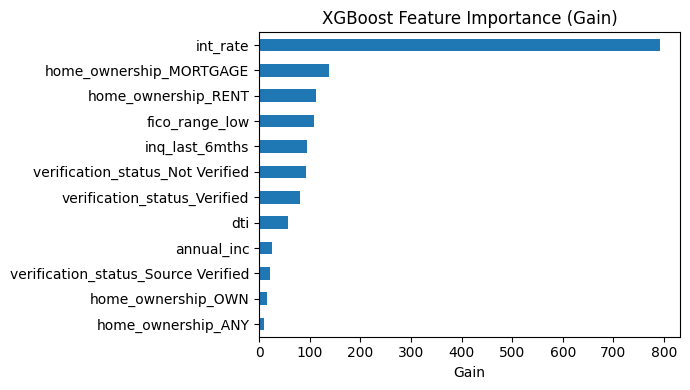

In [56]:
# Feature importance via XGBoost native gain metric
# Gain measures average improvement in loss from splits on each feature
importance = pd.Series(
    model_xgb.get_booster().get_score(importance_type='gain')
).sort_values(ascending=True)

importance.plot(kind='barh', figsize=(7, 4), title='XGBoost Feature Importance (Gain)')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()

### 3.6 Model Comparison and Production Model Selection

In [57]:
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression (Model A)', 'Logistic Regression (Model B)', 'XGBoost'],
    'Features' : ['Origination only', 'Origination + int_rate', 'Origination + int_rate'],
    'Test AUC' : [0.6327, 0.6763, xgb_auc]
})

print(comparison.to_string(index=False))

                        Model               Features  Test AUC
Logistic Regression (Model A)       Origination only  0.632700
Logistic Regression (Model B) Origination + int_rate  0.676300
                      XGBoost Origination + int_rate  0.689721


### Model Selection: Logistic Regression vs XGBoost

XGBoost achieves a marginally higher test AUC (0.690 vs 0.676) but is not selected as the production model for three reasons:

1. **Regulatory interpretability**: IFRS 9 and Basel provisioning models require explainable, auditable outputs. Logistic regression coefficients map directly to risk drivers; XGBoost does not.
2. **int_rate dominance**: XGBoost gain importance shows int_rate accounts for ~80% of predictive signal, raising endogeneity concerns since interest rate is itself a function of the lender's internal grade assessment.
3. **Marginal AUC gain**: A 1.3pp AUC improvement does not justify the interpretability tradeoff in a regulated provisioning context.

Logistic regression (Model B) is retained for all downstream ECL, IFRS 9 staging, and stress testing calculations.

In [58]:
# Assemble test-set PD scores from both models for downstream ECL calculations
# Model B (pricing-inclusive) used for IFRS 9 and stress testing - higher AUC
test_ids = df_test['id'].values

df_scores = pd.DataFrame({
    'id':            test_ids,
    'predicted_pd_a': model.predict_proba(X_test)[:, 1],
    'predicted_pd_b': model_B.predict_proba(X_test_B)[:, 1],
})
df_scores.head()

,id,predicted_pd_a,predicted_pd_b
0,130607974,0.207692,0.392006
1,130932509,0.167055,0.233670
2,130910225,0.202808,0.161246
3,130942737,0.227412,0.403589
4,130951046,0.075660,0.090164


## 4. Expected Loss Framework - LGD & EAD

The full expected loss equation under Basel and IFRS 9:

**ECL = PD × LGD × EAD**

- **PD** - Model B predicted probability of default  
- **LGD** (Loss Given Default) - estimated empirically from realised net principal losses on the 2016–2017 training cohort. Computed as `(loan_amnt − total_rec_prncp − recoveries) / loan_amnt`, capturing both principal repaid before default and post-charge-off recoveries. Segmented by loan grade — riskier grades carry higher LGD because lower-grade borrowers tend to default earlier, having repaid less principal.  
- **EAD** (Exposure at Default) - for fully drawn term loans, EAD = outstanding loan amount at origination. A Credit Conversion Factor (CCF) of 1.0 is applied - conservative and appropriate for non-revolving facilities.

In [59]:
#  LGD Estimation 
# df0 retains recoveries and loan_amnt (dropped from df_train/df_test for modeling only)
# Use 2016-2017 resolved defaults as the estimation cohort

df_lgd_src = df0[
    df0['issue_year'].isin(['2016', '2017']) &
    (df0['default_flag'] == 1)
].copy()

df_lgd_src['recovery_rate'] = ((df_lgd_src['total_rec_prncp'] + df_lgd_src['recoveries']) / df_lgd_src['loan_amnt']).clip(0, 1)
df_lgd_src['lgd']           = 1 - df_lgd_src['recovery_rate']

# Grade-level LGD - captures that riskier grades recover less
lgd_by_grade = (
    df_lgd_src.groupby('grade')['lgd']
    .agg(Count='count', Mean_LGD='mean', Median_LGD='median')
    .round(3)
)

portfolio_lgd = df_lgd_src['lgd'].mean()
print(f"Portfolio-level LGD: {portfolio_lgd:.3f}")
lgd_by_grade

Portfolio-level LGD: 0.593


,Count,Mean_LGD,Median_LGD
grade,,,
A,7902,0.487,0.481
B,30812,0.523,0.538
C,51421,0.583,0.616
D,30406,0.625,0.667
E,15542,0.675,0.720
F,6551,0.721,0.765
G,2696,0.745,0.786


In [60]:
#  EAD - merge loan_amnt and grade onto df_scores 
# df_test still carries all raw columns (only target-leaking cols were dropped)

df_portfolio = df_scores.merge(
    df_test[['id', 'loan_amnt', 'grade', 'term', 'default_flag']],
    on='id',
    how='left'
)

# Attach grade-level LGD
lgd_map = lgd_by_grade['Mean_LGD'].to_dict()
df_portfolio['lgd'] = df_portfolio['grade'].map(lgd_map).fillna(portfolio_lgd)

# EAD = loan_amnt (CCF = 1.0, term loans fully drawn at origination)
df_portfolio['ead'] = df_portfolio['loan_amnt']

df_portfolio[['id', 'grade', 'loan_amnt', 'predicted_pd_b', 'lgd', 'ead']].head(8)

,id,grade,loan_amnt,predicted_pd_b,lgd,ead
0,130607974,E,14100.0,0.392006,0.675,14100.0
1,130932509,C,20000.0,0.233670,0.583,20000.0
2,130910225,B,7000.0,0.161246,0.523,7000.0
3,130942737,D,21000.0,0.403589,0.625,21000.0
4,130951046,B,40000.0,0.090164,0.523,40000.0
5,130965526,C,13400.0,0.199464,0.583,13400.0
6,130967561,B,28000.0,0.136781,0.523,28000.0
7,130870739,B,6500.0,0.099317,0.523,6500.0


## 5. IFRS 9 - ECL Staging

IFRS 9 requires loans to be classified into three stages based on credit risk at the reporting date:

| Stage | Definition | ECL Horizon |
|-------|------------|-------------|
| **1** | No significant increase in credit risk (SICR) since origination | 12-month ECL |
| **2** | SICR has occurred - loan performing but risk elevated | Lifetime ECL |
| **3** | Credit-impaired - objective evidence of default | Lifetime ECL |

**Staging rules applied (origination-point proxy on 2018 cohort):**
- Stage 1: Model PD ≤ 10%
- Stage 2: 10% < Model PD ≤ 35% - SICR threshold
- Stage 3: Model PD > 35% - credit-impaired proxy

**12-month PD scaling:**  
The model outputs a lifetime PD. Stage 1 requires a 12-month ECL, so PD is scaled linearly: `PD_12m = PD_lifetime × (12 / term_months)`. This is a simplification - in production, a vintage survival curve or hazard model would be used.

In [61]:
#  IFRS 9 Stage Assignment 
STAGE2_THRESHOLD = 0.10   # SICR trigger
STAGE3_THRESHOLD = 0.35   # Credit-impaired proxy

def assign_stage(pd_score):
    if pd_score > STAGE3_THRESHOLD:
        return 3
    elif pd_score > STAGE2_THRESHOLD:
        return 2
    else:
        return 1

df_portfolio['stage'] = df_portfolio['predicted_pd_b'].apply(assign_stage)

# 12-month PD for Stage 1 (linear interpolation over loan term)
df_portfolio['pd_12m']      = df_portfolio['predicted_pd_b'] * (12 / df_portfolio['term'])
df_portfolio['pd_lifetime'] = df_portfolio['predicted_pd_b']

stage_counts = df_portfolio['stage'].value_counts().sort_index()
print("Stage distribution:")
print(stage_counts.to_string())
print(f"\nTotal loans: {len(df_portfolio):,}  |  Portfolio EAD: ${df_portfolio['ead'].sum():,.0f}")

Stage distribution:
stage
1     42547
2    127008
3     27112

Total loans: 196,667  |  Portfolio EAD: $3,013,678,700


In [62]:
#  ECL Calculation 
# Stage 1: 12-month ECL  |  Stage 2 & 3: lifetime ECL

df_portfolio['pd_for_ecl'] = df_portfolio.apply(
    lambda r: r['pd_12m'] if r['stage'] == 1 else r['pd_lifetime'], axis=1
)

df_portfolio['ecl'] = df_portfolio['pd_for_ecl'] * df_portfolio['lgd'] * df_portfolio['ead']

#  Portfolio ECL Summary by Stage 
ecl_summary = df_portfolio.groupby('stage').agg(
    Loan_Count   = ('id',       'count'),
    Total_EAD    = ('ead',      'sum'),
    Avg_PD       = ('predicted_pd_b', 'mean'),
    Avg_LGD      = ('lgd',      'mean'),
    Total_ECL    = ('ecl',      'sum'),
).round(2)

ecl_summary['ECL_%_of_EAD']     = (ecl_summary['Total_ECL'] / ecl_summary['Total_EAD'] * 100).round(2)
ecl_summary['Avg_PD']           = ecl_summary['Avg_PD'].round(3)
ecl_summary['Avg_LGD']          = ecl_summary['Avg_LGD'].round(3)

total_ecl = df_portfolio['ecl'].sum()
total_ead = df_portfolio['ead'].sum()
print(f"Total ECL: ${total_ecl:,.0f}  |  Coverage Ratio: {total_ecl/total_ead*100:.2f}%")
ecl_summary

Total ECL: $352,525,328  |  Coverage Ratio: 11.70%


,Loan_Count,Total_EAD,Avg_PD,Avg_LGD,Total_ECL,ECL_%_of_EAD
stage,,,,,,
1,42547,6.358214e+08,0.06,0.49,5.845328e+06,0.92
2,127008,1.953226e+09,0.21,0.56,2.347854e+08,12.02
3,27112,4.246309e+08,0.41,0.64,1.118946e+08,26.35


## 6. Stress Testing - ECL Under Macro Scenarios

PD multipliers are applied to simulate deteriorating macro conditions. This mirrors the ICAAP stress testing approach: the model captures through-the-cycle (TTC) PD; scenario overlays shift it toward point-in-time (PIT) conditions representing different economic states.

| Scenario | PD Multiplier | Rationale |
|----------|--------------|-----------|
| **Base** | 1.0× | Model PD as calibrated |
| **Adverse** | 1.5× | Mild recession - moderate credit deterioration |
| **Severe** | 2.5× | Severe downturn - GFC-style stress |

PD is capped at 1.0. Stages are re-assigned under each scenario, which causes migration from Stage 1 → Stage 2/3 and switches ECL from 12-month to lifetime horizon - amplifying the ECL uplift beyond the raw PD increase alone.

In [78]:
#  Scenario ECL Calculator 
def compute_scenario_ecl(df, pd_multiplier, label):
    d = df.copy()
    d['stressed_pd'] = (d['predicted_pd_b'] * pd_multiplier).clip(upper=1.0)
    d['stage']       = d['stressed_pd'].apply(assign_stage)
    d['pd_12m']      = d['stressed_pd'] * (12 / d['term'])
    d['pd_for_ecl']  = d.apply(lambda r: r['pd_12m'] if r['stage'] == 1 else r['stressed_pd'], axis=1)
    d['ecl']         = d['pd_for_ecl'] * d['lgd'] * d['ead']

    by_stage = d.groupby('stage')['ecl'].sum()
    return {
        'Scenario'      : label,
        'PD_Multiplier' : f'{pd_multiplier}x',
        'Stage_1_ECL'   : by_stage.get(1, 0),
        'Stage_2_ECL'   : by_stage.get(2, 0),
        'Stage_3_ECL'   : by_stage.get(3, 0),
        'Total_ECL'     : d['ecl'].sum(),
        'Coverage_%'    : d['ecl'].sum() / d['ead'].sum() * 100,
    }

scenarios = [
    compute_scenario_ecl(df_portfolio, 1.0, 'Base'),
    compute_scenario_ecl(df_portfolio, 1.5, 'Adverse'),
    compute_scenario_ecl(df_portfolio, 2.5, 'Severe'),
]

stress_df = pd.DataFrame(scenarios).set_index('Scenario')
stress_df[['Stage_1_ECL','Stage_2_ECL','Stage_3_ECL','Total_ECL']] = (
    stress_df[['Stage_1_ECL','Stage_2_ECL','Stage_3_ECL','Total_ECL']].applymap(lambda x: f'${x:,.0f}')
)
stress_df['Coverage_%'] = stress_df['Coverage_%'].astype(float).round(2)
stress_df

,PD_Multiplier,Stage_1_ECL,Stage_2_ECL,Stage_3_ECL,Total_ECL,Coverage_%
Scenario,,,,,,
Base,1.0x,"$5,845,328","$234,785,419","$111,894,582","$352,525,328",11.70
Adverse,1.5x,"$4,813,803","$163,650,008","$369,613,545","$538,077,356",17.85
Severe,2.5x,"$1,157,070","$114,814,020","$780,142,697","$896,113,787",29.73


In [64]:
#  ECL Uplift vs Base 
base_ecl = compute_scenario_ecl(df_portfolio, 1.0, 'Base')['Total_ECL']

uplift = pd.DataFrame([
    {
        'Scenario'      : s['Scenario'],
        'Total_ECL'     : s['Total_ECL'],
        'Uplift_vs_Base': (s['Total_ECL'] - base_ecl) / base_ecl * 100
    }
    for s in [
        compute_scenario_ecl(df_portfolio, 1.0, 'Base'),
        compute_scenario_ecl(df_portfolio, 1.5, 'Adverse'),
        compute_scenario_ecl(df_portfolio, 2.5, 'Severe'),
    ]
]).set_index('Scenario')

uplift['Total_ECL']      = uplift['Total_ECL'].apply(lambda x: f'${x:,.0f}')
uplift['Uplift_vs_Base'] = uplift['Uplift_vs_Base'].apply(lambda x: f'+{x:.1f}%' if x > 0 else f'{x:.1f}%')
uplift

,Total_ECL,Uplift_vs_Base
Scenario,,
Base,"$352,525,328",0.0%
Adverse,"$538,077,356",+52.6%
Severe,"$896,113,787",+154.2%


## 7. Backtest Validation - Provisioned ECL vs. Actual Losses

Since the 2018 test cohort is fully resolved (outcomes known), we can validate whether the IFRS 9 provisioning framework was adequate. This is the core of model validation in a provisioning context.

**Setup:**  
- The 2018 loans were treated as a live portfolio at origination - model PD applied, stages assigned, ECL provisioned *without* looking at actual outcomes  
- Actual net loss = `loan_amnt − total_rec_prncp − recoveries` on defaulted loans (zero for performing loans)  
- Coverage ratio = Provisioned ECL / Actual Loss - a ratio below 1.0x indicates under-provisioning

In [65]:
#  Actual Loss from df0 (has total_rec_prncp and recoveries) 
df_actual = df0[df0['issue_year'] == '2018'].copy()

# Actual net loss on defaulted loans
df_actual['actual_loss'] = df_actual.apply(
    lambda r: max(r['loan_amnt'] - r['total_rec_prncp'] - r['recoveries'], 0)
              if r['default_flag'] == 1 else 0,
    axis=1
)

# Merge onto portfolio df
df_backtest = df_portfolio.merge(
    df_actual[['id', 'actual_loss']],
    on='id', how='left'
).fillna({'actual_loss': 0})

#  Portfolio-level comparison 
total_provisioned = df_backtest['ecl'].sum()
total_actual      = df_backtest['actual_loss'].sum()
coverage_ratio    = total_provisioned / total_actual if total_actual > 0 else float('inf')

print(f"Total Provisioned ECL : ${total_provisioned:>12,.0f}")
print(f"Total Actual Loss     : ${total_actual:>12,.0f}")
print(f"Coverage Ratio        : {coverage_ratio:.2f}x  ({'OVER' if coverage_ratio >= 1 else 'UNDER'}-provisioned)")

Total Provisioned ECL : $ 352,525,328
Total Actual Loss     : $ 606,324,280
Coverage Ratio        : 0.58x  (UNDER-provisioned)


In [66]:
#  Coverage by Stage 
backtest_by_stage = df_backtest.groupby('stage').agg(
    Loan_Count        = ('id',           'count'),
    Provisioned_ECL   = ('ecl',          'sum'),
    Actual_Loss       = ('actual_loss',  'sum'),
).round(0)

backtest_by_stage['Coverage_Ratio'] = (
    backtest_by_stage['Provisioned_ECL'] / backtest_by_stage['Actual_Loss'].replace(0, float('nan'))
).round(2)

print("Backtest summary by stage:")
print(backtest_by_stage)

Backtest summary by stage:
       Loan_Count  Provisioned_ECL  Actual_Loss  Coverage_Ratio
stage                                                          
1           42547        5845328.0   46223736.0            0.13
2          127008      234785419.0  410606902.0            0.57
3           27112      111894582.0  149493642.0            0.75


## 8. Underwriting Policy Simulation - Risk-Based Rejection

A risk-based cutoff policy rejects the top 30% riskiest applications by predicted PD. This quantifies the reduction in expected loss against the volume trade-off (lost origination).

Two loss metrics are compared:
- **Provisioned ECL** - model-estimated loss (forward-looking)
- **Actual Loss** - realised net charge-offs (backtest ground truth)

The gap between the two reflects the calibration shortfall identified above.

In [67]:
#  Policy Simulation 
cutoff_pct   = 0.30   # Reject top 30% by predicted PD
pd_cutoff    = df_portfolio['predicted_pd_b'].quantile(1 - cutoff_pct)

df_accepted  = df_portfolio[df_portfolio['predicted_pd_b'] <= pd_cutoff].copy()
df_rejected  = df_portfolio[df_portfolio['predicted_pd_b'] >  pd_cutoff].copy()

# ECL components
ecl_all      = df_portfolio['ecl'].sum()
ecl_accepted = df_accepted['ecl'].sum()
ecl_rejected = df_rejected['ecl'].sum()

# Actual loss components (using df_backtest which has actual_loss)
df_bt_accepted = df_backtest[df_backtest['predicted_pd_b'] <= pd_cutoff]
df_bt_rejected = df_backtest[df_backtest['predicted_pd_b'] >  pd_cutoff]

actual_all      = df_backtest['actual_loss'].sum()
actual_accepted = df_bt_accepted['actual_loss'].sum()
actual_rejected = df_bt_rejected['actual_loss'].sum()

print(f"PD cutoff (70th pctile): {pd_cutoff:.3f}")
print()
print(f"{'Metric':<35} {'All Portfolio':>15} {'Accepted (70%)':>15} {'Rejected (30%)':>15}")
print('-' * 83)
print(f"{'Loan Count':<35} {len(df_portfolio):>15,} {len(df_accepted):>15,} {len(df_rejected):>15,}")
print(f"{'Total EAD':<35} ${df_portfolio['ead'].sum():>14,.0f} ${df_accepted['ead'].sum():>14,.0f} ${df_rejected['ead'].sum():>14,.0f}")
print(f"{'Provisioned ECL':<35} ${ecl_all:>14,.0f} ${ecl_accepted:>14,.0f} ${ecl_rejected:>14,.0f}")
print(f"{'Actual Loss (backtest)':<35} ${actual_all:>14,.0f} ${actual_accepted:>14,.0f} ${actual_rejected:>14,.0f}")
print()
print(f"EL reduction (provisioned): {ecl_rejected / ecl_all * 100:.1f}%")
print(f"EL reduction (actual loss): {actual_rejected / actual_all * 100:.1f}%")

PD cutoff (70th pctile): 0.272

Metric                                All Portfolio  Accepted (70%)  Rejected (30%)
-----------------------------------------------------------------------------------
Loan Count                                  196,667         137,668          58,999
Total EAD                           $ 3,013,678,700 $ 2,105,161,325 $   908,517,375
Provisioned ECL                     $   352,525,328 $   151,742,811 $   200,782,518
Actual Loss (backtest)              $   606,324,280 $   325,441,855 $   280,882,425

EL reduction (provisioned): 57.0%
EL reduction (actual loss): 46.3%


**Interpretation - calibration vs. discrimination:**

The portfolio-level coverage ratio is **0.58x** - the model under-provisioned by approximately 42%. The stage breakdown reveals where the shortfall is concentrated:

| Bucket | Coverage Ratio |
|--------|---------------|
| Rejected (top 30% PD) | ~0.71x, under-provisioned |
| Accepted (bottom 70% PD) | ~0.47x, materially under-provisioned |

This is a **calibration failure, not a discrimination failure**. The model correctly rank-ordered risk (AUC, KS confirm this) and concentrated predicted losses in the right loans. But it under-estimated the absolute magnitude of loss across all segments.

The calibration shortfall is attributable to PD under-estimation, as logistic regression on imbalanced data tends to compress predicted probabilities toward the mean. The LGD estimates are correctly computed as net principal loss (loan amount less principal recovered before default and post-charge-off recoveries), consistent with the backtest actual loss definition. In a production context, the next step would be a PD calibration exercise, scaling output probabilities to match observed default rates while leaving the rank ordering and scorecard structure unchanged.

## 9. Summary

This notebook develops a complete Basel/IFRS 9-aligned credit risk framework on ~900k resolved Lending Club loans:

| Component | Result |
|-----------|--------|
| **PD - Model A** (origination features) | Test AUC 0.633, Gini 0.265, KS ~0.19 |
| **PD - Model B** (+ interest rate) | Test AUC 0.676, Gini 0.353, KS ~0.26 |
| **XGBoost benchmark** | Test AUC ~0.690, marginal gain, not selected |
| **Portfolio LGD** (grade-weighted) | 0.593, net principal loss basis, Grade A: 0.487 to Grade G: 0.745 |
| **Portfolio ECL** (base scenario) | $352.5M, Coverage ratio 0.58x vs. realised losses |
| **Stress uplift** | Adverse +~53%, Severe +~154% vs. base ECL |
| **Policy simulation** | Top-30% rejection removes ~57% of provisioned ECL, ~46% of actual loss |

**Key findings:**

The backtest reveals a calibration shortfall, not a discrimination failure. Model B correctly rank-orders risk (AUC and KS are stable out-of-sample) but systematically under-estimates absolute loss magnitude across all stages (Stage 1: 0.13x, Stage 2: 0.57x, Stage 3: 0.75x). LGD is estimated on a net principal loss basis, `(loan_amnt - total_rec_prncp - recoveries) / loan_amnt`, consistent with the backtest actual loss definition. This correctly captures that riskier grades carry higher severity (Grade G LGD 0.745 vs Grade A 0.487) because lower-grade borrowers default earlier in the loan lifecycle having repaid less principal. The under-provisioning is attributable to PD under-calibration, a known property of logistic regression on imbalanced data. In a production setting, the next step would be a PD calibration exercise, scaling output probabilities to observed default rates while leaving the rank ordering and scorecard structure unchanged.

XGBoost was benchmarked but not selected. The 1.3pp AUC improvement does not justify the loss of regulatory interpretability required for IFRS 9 provisioning and Basel model governance.